In [ ]:
import pandas as pd
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
results_path = "/home/schmied.christopher/FMP_Docs/Projects/eu_os_ecbl_qc/QC_Results/"

In [5]:
fmp_qc = pd.read_excel(os.path.join(results_path, 'FMP_QC_Summary_Updated.xlsx'), sheet_name="Sheet1")
imtm_qc = pd.read_excel(os.path.join(results_path, 'IMTM_QC_Summary_Updated.xlsx'), sheet_name="Sheet1")
medina_qc = pd.read_excel(os.path.join(results_path, 'Medina_QC_Summary_Updated.xlsx'), sheet_name="Sheet1")
usc_qc = pd.read_excel(os.path.join(results_path, 'USC_QC_Summary_Updated.xlsx'), sheet_name="Sheet1")

In [ ]:
usc_qc.head()

,plate_map_name,plate,replicate,batch_date,run,site_qc,note_experiment,visible artifacts,heatmap,cell_number,comment,intra_plate,intra_batch,inter_batch,qc_summary,note
0,C1157_R1,C1157,R1,2024-06-13,First Run,NaN,Replicates in same batch,NaN,pass,flag,too high,pass,pass,flag,pass,Inter batch QC Flag Tetrandrine
1,C1157_R2,C1157,R2,2024-06-13,First Run,NaN,Replicates in same batch,NaN,pass,flag,too high,flag,pass,flag,repeat,Inter batch QC Flag Tetrandrine
2,C1157_R3,C1157,R3,2024-06-13,First Run,NaN,Replicates in same batch,NaN,pass,flag,too high,pass,pass,flag,repeat,Inter batch QC Flag Tetrandrine
3,C1157_R4,C1157,R4,2024-06-13,First Run,NaN,NaN,NaN,pass,pass,NaN,pass,pass,flag,repeat,Inter batch QC Flag Tetrandrine
4,C1158_R1,C1158,R1,2024-06-13,First Run,NaN,NaN,NaN,pass,pass,NaN,pass,pass,flag,pass,Inter batch QC Flag Tetrandrine


In [7]:
heatmap_col = "heatmap"
cellnum_col = "cell_number"
corr_cols   = ["intra_plate", "intra_batch", "inter_batch"]
all_cols    = [heatmap_col, cellnum_col] + corr_cols

def _is_fail(s: pd.Series) -> pd.Series:
    # robust to NaNs and mixed dtypes
    return s.astype(str).str.strip().str.lower().eq("fail")

def compute_qc_summary(df: pd.DataFrame) -> pd.Series:
    # Gracefully handle missing columns (treat as no-fail if missing)
    present_corr = [c for c in corr_cols if c in df.columns]
    present_all  = [c for c in all_cols if c in df.columns]

    if heatmap_col in df:
        hm_fail = _is_fail(df[heatmap_col])
    else:
        hm_fail = pd.Series(False, index=df.index)

    if cellnum_col in df:
        cn_fail = _is_fail(df[cellnum_col])
    else:
        cn_fail = pd.Series(False, index=df.index)

    if present_corr:
        corr_fail = df[present_corr].apply(_is_fail).any(axis=1)
    else:
        corr_fail = pd.Series(False, index=df.index)

    if present_all:
        total_fail = (
            df[present_all]
            .apply(lambda col: col.astype(str).str.strip().str.lower().eq("fail"))
            .any(axis=1)
            .sum()
        )
        total_tested = df[present_all].notna().any(axis=1).sum()
    else:
        total_fail = 0
        total_tested = 0

    return pd.Series({
        "heatmap": hm_fail.sum(),
        "cell-number": cn_fail.sum(),
        "correlation": corr_fail.sum(),
        "total_fail": total_fail,
        "heatmap_cell-number": (hm_fail & cn_fail).sum(),
        "heatmap_correlation": (hm_fail & corr_fail).sum(),
        "cell-number_correlation": (cn_fail & corr_fail).sum(),
        "heatmap_cell-number_correlation": (hm_fail & cn_fail & corr_fail).sum(),
        "total_tested": total_tested,
    })

In [8]:
# ---- Apply to many dataframes and combine ----

# Example: a dict of dataframes you want to summarize
# keys become dataset labels in the output


def summarize_many(dataframes: dict) -> pd.DataFrame:
    rows = []
    for name, df in dataframes.items():
        s = compute_qc_summary(df)
        s.name = name
        rows.append(s)
    wide = pd.concat(rows, axis=1).T  # one row per dataset, columns are metrics
    wide.index.name = "dataset"
    wide = wide.reset_index()
    return wide

def to_long_for_plotting(wide_df: pd.DataFrame) -> pd.DataFrame:
    # Tidy/long format: dataset | metric | count
    long = wide_df.melt(id_vars="dataset", var_name="metric", value_name="count")
    # keep only desired metrics
    long = long[long["metric"].isin(["heatmap", "cell-number", "correlation"])]
    return long

In [9]:
dataframes = {"FMP": fmp_qc, "IMTM": imtm_qc , "MEDINA": medina_qc, "USC": usc_qc}



In [10]:
wide_summary = summarize_many(dataframes)
wide_summary

,dataset,heatmap,cell-number,correlation,total_fail,heatmap_cell-number,heatmap_correlation,cell-number_correlation,heatmap_cell-number_correlation,total_tested
0,FMP,69,31,83,161,8,14,2,2,429
1,IMTM,11,1,13,23,1,1,0,0,431
2,MEDINA,11,5,6,18,2,2,1,1,312
3,USC,3,1,7,10,0,0,1,0,343


In [11]:
wide_summary["total_fail"].sum()

np.int64(212)

In [12]:
wide_summary["total_tested"].sum()

np.int64(1515)

In [13]:
long_summary = to_long_for_plotting(wide_summary)
long_summary

,dataset,metric,count
0,FMP,heatmap,69
1,IMTM,heatmap,11
2,MEDINA,heatmap,11
3,USC,heatmap,3
4,FMP,cell-number,31
5,IMTM,cell-number,1
6,MEDINA,cell-number,5
7,USC,cell-number,1
8,FMP,correlation,83
9,IMTM,correlation,13


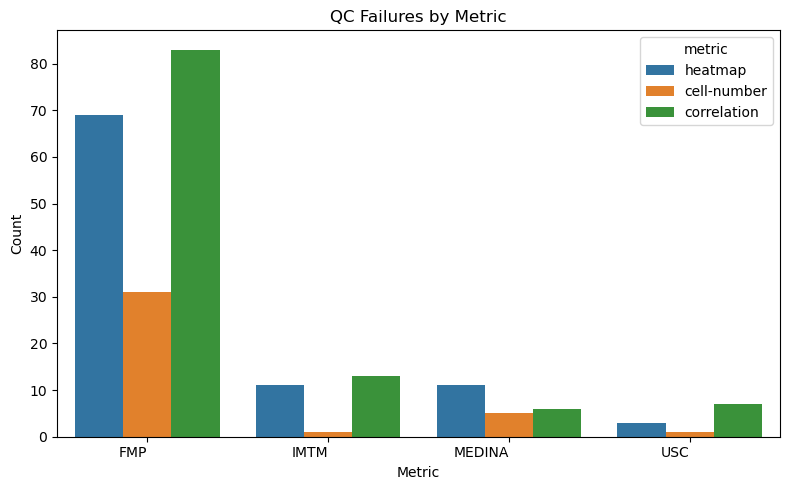

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=long_summary, 
            x="dataset", 
            y="count", 
            hue="metric")
plt.xticks(ha="right")
plt.title("QC Failures by Metric")
plt.xlabel("Metric")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig("qc_failures.svg", format="svg")
plt.show()

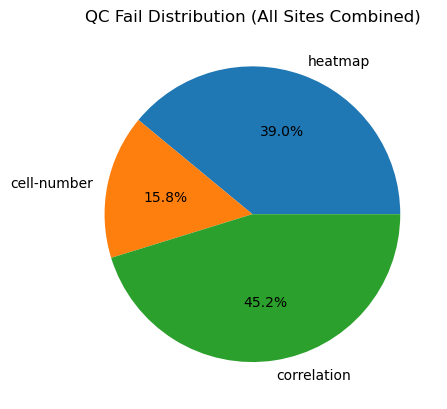

In [15]:
qc_cols = [
    "heatmap",
    "cell-number",
    "correlation"
]

total_counts = wide_summary[qc_cols].sum()

plt.figure()
plt.pie(total_counts, labels=qc_cols, autopct='%1.1f%%')
plt.title("QC Fail Distribution (All Sites Combined)")
plt.show()

In [16]:
df = wide_summary.copy()

# --- aggregate totals across all sites ---
tot = df.sum(numeric_only=True)

# shorthand
H = tot["heatmap"]
C = tot["cell-number"]
R = tot["correlation"]

HC = tot["heatmap_cell-number"]
HR = tot["heatmap_correlation"]
CR = tot["cell-number_correlation"]

HCR = tot["heatmap_cell-number_correlation"]

total_tested = tot["total_tested"]
total_fail = tot["total_fail"]

# --- compute mutually exclusive categories ---
only_H = H - HC - HR + HCR
only_C = C - HC - CR + HCR
only_R = R - HR - CR + HCR

only_HC = HC - HCR
only_HR = HR - HCR
only_CR = CR - HCR

only_HCR = HCR

# pass
pass_plates = total_tested - total_fail


In [17]:
# --- define overlap as ALL multi-fail cases ---
overlap = only_HC + only_HR + only_CR + only_HCR

labels = [
    "Pass",
    "Fail Heatmap",
    "Fail Cell-Number",
    "Fail Correlation",
    "Fail Multiple"
]

sizes = [
    pass_plates,
    only_H,
    only_C,
    only_R,
    overlap
]

In [26]:
colors = [
    '#2ca02c',  # Pass - green
    '#e74c3c',  # Fail Heatmap - red
    '#c0392b',  # Fail Cell-Number - darker red
    '#922b21',  # Fail Correlation - even darker red
    '#641e16',  # Fail Multiple - deepest red
]

In [27]:
labels_clean = []
sizes_clean = []

for l, s in zip(labels, sizes):
    if s > 0:
        labels_clean.append(l)
        sizes_clean.append(s)

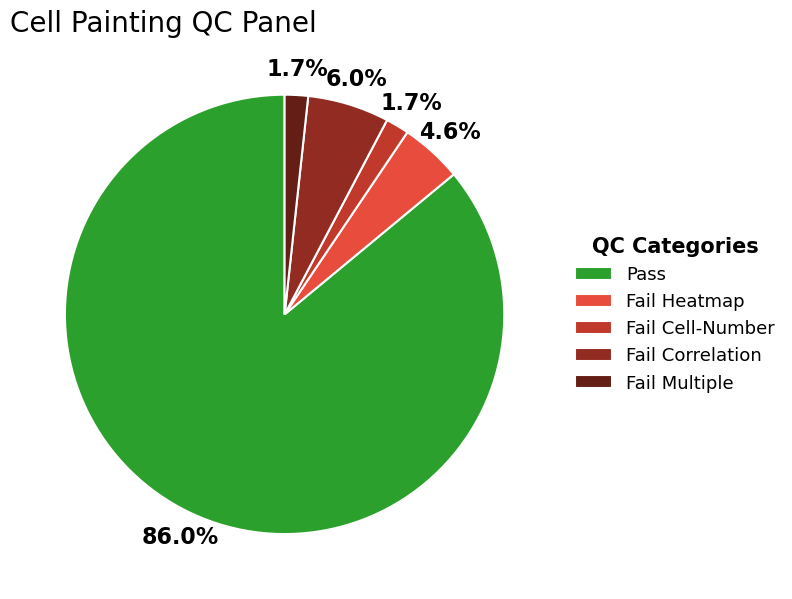

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))

wedges, _ = ax.pie(
    sizes_clean,
    colors=colors,
    labels=None,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

# --- add percentages outside (no lines) ---
total = sum(sizes_clean)

for i, w in enumerate(wedges):
    angle = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    percentage = sizes_clean[i] / total * 100

    ax.text(
        1.12 * x, 
        1.12 * y,
        f"{percentage:.1f}%",
        ha='center',
        va='center',
        fontsize=16,
        fontweight='bold'
    )

# legend
ax.legend(
    wedges,
    labels_clean,
    title="QC Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=13,
    title_fontproperties={'weight': 'bold', 'size': 15},
    frameon=False
)

ax.set_title(
    "Cell Painting QC Panel",
    fontsize=20,
    loc='left'  
)

plt.tight_layout()
plt.savefig("qc_failure_pie.pdf", bbox_inches='tight')
plt.show()